# ⭐ OJALA Star Sample Selection

This notebook builds a **quality-controlled stellar subcatalogue** from the global OJALA catalogue and produces a set of validation plots.

It includes:

- ✂️ quality cuts
- 🧪 parameter-based stellar selection
- 🖼️ visual inspection of a few stellar J-PAS photo-spectra
- 📊 scatter plots with stellar parameters
- 💾 export of the final stellar subcatalogue

## 📦 Imports and plotting style

We load the required packages and set a dark plotting style for consistency with the rest of the OJALA validation notebooks.

In [39]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.style.use("dark_background")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "lines.linewidth": 2.2,
    "axes.grid": False,
})

## ⚙️ User configuration

Edit these paths and thresholds before running the notebook.

All selection cuts are defined here in one place.

In [48]:
# ---------------------------------------------------------------------
# USER CONFIGURATION
# ---------------------------------------------------------------------
REPO_ROOT = Path.cwd().resolve()

INPUT_CATALOG = REPO_ROOT / "data" / "catalogues" / "JPAS_EDR_photometry_APER_COR_3_0_OJALA_catalog.csv"
OUTPUT_DIR = REPO_ROOT / "data" / "catalogues"

# Main selection cuts
MAG_I_MAX = 21.0
P_STAR_MIN = 0.9
MIN_VALID_JPAS_FILTERS = 54

# Optional class filter
USE_CLASS_FILTER = True
CLASS_COL = "CLASS"
CLASS_TARGET = "STAR"

# JPAS photometry prefix used to build the OJALA input features
JPAS_PHOT_PREFIX = "APER_COR_3_0"

# Column names
MAG_I_COL = "MAG_i"
P_STAR_COL = "P_STAR"
P_GALAXY_COL = "P_GALAXY"

TEFF_COL = "TEFF"
LOGG_COL = "LOGG"
ALPHAFE_COL = "ALPHAFE"
FEH_COL = "FEH"

# Visual inspection of random stars
N_RANDOM_STAR_EXAMPLES = 6
RANDOM_SEED = 42

# Plot settings
FIG_DPI = 180
POINT_SIZE = 10
ALPHA_SCATTER = 0.70
FIGSIZE = (8, 6)

## 🌈 J-PAS filters and effective wavelengths

We define the J-PAS narrow-band filters and their central wavelengths.

In [41]:
FILTER_JPAS = [
    "J0378", "J0390", "J0400", "J0410", "J0420", "J0430", "J0440", "J0450",
    "J0460", "J0470", "J0480", "J0490", "J0500", "J0510", "J0520", "J0530",
    "J0540", "J0550", "J0560", "J0570", "J0580", "J0590", "J0600", "J0610",
    "J0620", "J0630", "J0640", "J0650", "J0660", "J0670", "J0680", "J0690",
    "J0700", "J0710", "J0720", "J0730", "J0740", "J0750", "J0760", "J0770",
    "J0780", "J0790", "J0800", "J0810", "J0820", "J0830", "J0840", "J0850",
    "J0860", "J0870", "J0880", "J0890", "J0900", "J0910"
]

EFF_WAVE_JPAS = {band: float(band[1:]) for band in FILTER_JPAS}

## 🧰 Helper functions

These functions handle:

- directory creation
- validation of required columns
- quality cuts
- robust plotting limits
- stellar parameter selection

In [42]:
def ensure_output_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)


def get_jpas_input_columns(prefix):
    return [f"{prefix}_{filt}" for filt in FILTER_JPAS]


def validate_required_columns(df, required_columns):
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError("Missing required columns in the catalogue:\n" + "\n".join(missing))


def count_valid_jpas_filters(df, jpas_columns):
    return df[jpas_columns].notna().sum(axis=1)


def finite_mask(*arrays):
    mask = np.ones(len(arrays[0]), dtype=bool)
    for arr in arrays:
        arr = np.asarray(arr)
        mask &= np.isfinite(arr)
    return mask


def smart_limits(values, pad_frac=0.08, qlow=0.01, qhigh=0.99, fallback=(-1, 1)):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]

    if arr.size == 0:
        return fallback

    vmin = np.nanquantile(arr, qlow)
    vmax = np.nanquantile(arr, qhigh)

    if not np.isfinite(vmin) or not np.isfinite(vmax):
        return fallback

    if vmax <= vmin:
        delta = 0.5 if vmax == vmin else abs(vmax - vmin)
        return (vmin - delta, vmax + delta)

    pad = pad_frac * (vmax - vmin)
    return (vmin - pad, vmax + pad)


def apply_star_selection(
    df,
    mag_i_col,
    p_star_col,
    jpas_columns,
    mag_i_max,
    p_star_min,
    min_valid_jpas_filters,
    teff_col,
    logg_col,
    alphafe_col,
    feh_col,
    use_class_filter=False,
    class_col=None,
    class_target="STAR",
):
    selected = df.copy()

    selected["N_VALID_JPAS_FILTERS"] = count_valid_jpas_filters(selected, jpas_columns)

    mask = np.ones(len(selected), dtype=bool)
    mask &= pd.to_numeric(selected[mag_i_col], errors="coerce") < mag_i_max
    mask &= pd.to_numeric(selected[p_star_col], errors="coerce") >= p_star_min
    mask &= pd.to_numeric(selected["N_VALID_JPAS_FILTERS"], errors="coerce") >= min_valid_jpas_filters

    mask &= pd.to_numeric(selected[teff_col], errors="coerce").notna().values
    mask &= pd.to_numeric(selected[logg_col], errors="coerce").notna().values
    mask &= pd.to_numeric(selected[alphafe_col], errors="coerce").notna().values
    mask &= pd.to_numeric(selected[feh_col], errors="coerce").notna().values

    if use_class_filter and class_col is not None and class_col in selected.columns:
        mask &= selected[class_col].astype(str).values == class_target

    return selected.loc[mask].copy()


def apply_example_parameter_cuts(
    df,
    teff_col,
    logg_col,
    alphafe_col,
    feh_col,
    teff_min,
    teff_max,
    logg_min,
    logg_max,
    alphafe_min,
    alphafe_max,
    feh_min,
    feh_max,
):
    out = df.copy()

    mask = np.ones(len(out), dtype=bool)
    mask &= pd.to_numeric(out[teff_col], errors="coerce").between(teff_min, teff_max).values
    mask &= pd.to_numeric(out[logg_col], errors="coerce").between(logg_min, logg_max).values
    mask &= pd.to_numeric(out[alphafe_col], errors="coerce").between(alphafe_min, alphafe_max).values
    mask &= pd.to_numeric(out[feh_col], errors="coerce").between(feh_min, feh_max).values

    return out.loc[mask].copy()

## 📥 Load the catalogue

We now read the global OJALA catalogue 

In [8]:
ensure_output_dir(OUTPUT_DIR)

print("Reading catalogue...")
df = pd.read_csv(INPUT_CATALOG)

jpas_columns = get_jpas_input_columns(JPAS_PHOT_PREFIX)

required_columns = [
    MAG_I_COL,
    P_STAR_COL,
    P_GALAXY_COL,
    TEFF_COL,
    LOGG_COL,
    ALPHAFE_COL,
    FEH_COL,
] + jpas_columns

if USE_CLASS_FILTER:
    required_columns.append(CLASS_COL)

validate_required_columns(df, required_columns)

print(f"Number of objects in catalogue: {len(df):,}")
print(f"Number of columns in catalogue: {len(df.columns):,}")

Reading catalogue...
Number of objects in catalogue: 675,672
Number of columns in catalogue: 317


## ✂️ Apply stellar selection

This creates the science-ready stellar catalogue.

In [43]:
star_df = apply_star_selection(
    df=df,
    mag_i_col=MAG_I_COL,
    p_star_col=P_STAR_COL,
    jpas_columns=jpas_columns,
    mag_i_max=MAG_I_MAX,
    p_star_min=P_STAR_MIN,
    min_valid_jpas_filters=MIN_VALID_JPAS_FILTERS,
    teff_col=TEFF_COL,
    logg_col=LOGG_COL,
    alphafe_col=ALPHAFE_COL,
    feh_col=FEH_COL,
    use_class_filter=USE_CLASS_FILTER,
    class_col=CLASS_COL,
    class_target=CLASS_TARGET,
)

print(f"Selected star objects: {len(star_df):,}")
star_df.head()

Selected star objects: 42,043


,TILE_ID,NUMBER,ALPHA_J2000,DELTA_J2000,CLASS_STAR,FWHM_WORLD,KRON_RADIUS,A_WORLD,B_WORLD,R_EFF,...,FLUX_HBETA_ERR,FLUX_OIII5007,FLUX_OIII5007_ERR,FLUX_NII6584,FLUX_NII6584_ERR,HA_HB_RATIO,L_HALPHA_CORR,LOGSFR_HA,LOGSFR_HA_ERR,N_VALID_JPAS_FILTERS
183,9611,41579,245.920881,43.978210,0.842773,0.000281,3.5,0.000107,0.000104,1.648042,...,5.981686e-17,1.190711e-16,8.869846e-17,3.612970e-17,2.846499e-17,2.619678,4.532361e+40,-0.446048,2.198146,54
186,9611,50830,245.921021,43.820669,0.918457,0.000250,3.5,0.000101,0.000100,1.578045,...,1.950559e-16,1.365821e-16,6.483637e-17,2.929469e-16,1.469461e-16,1.775426,1.517911e+42,1.078873,0.856979,54
197,9611,52716,245.921448,43.789574,0.774902,0.000265,3.5,0.000103,0.000102,1.626469,...,1.529949e-16,1.249055e-16,5.071565e-17,2.984764e-16,1.568690e-16,2.201617,1.313566e+42,1.016079,0.896481,54
198,9611,37949,245.921587,44.043093,0.857910,0.000259,3.5,0.000100,0.000098,1.563656,...,6.841072e-18,5.194223e-17,2.285728e-17,1.641345e-16,8.589895e-17,3.022784,6.268806e+41,0.694812,0.710415,54
244,9611,49753,245.924150,43.838896,0.923340,0.000256,3.5,0.000099,0.000097,1.523259,...,2.569345e-18,1.824336e-17,8.514686e-18,4.514079e-17,1.279716e-17,5.556774,1.107997e+42,0.942166,0.588749,54


## 🧪 Select a sub-sample for stellar examples

Here we define the parameter cuts used only to display representative stellar J-PAS photo-spectra.


In [61]:
# ---------------------------------------------------------------------
# Parameter cuts for the stellar examples shown below
# Edit these values freely to inspect different kinds of stars
# ---------------------------------------------------------------------

# Stellar parameter cuts
TEFF_MIN = 3500
TEFF_MAX = 8000

LOGG_MIN = 3.5
LOGG_MAX = 5.2

FEH_MIN = -2.5
FEH_MAX = 0.7

ALPHAFE_MIN = -0.2
ALPHAFE_MAX = 0.6

# Additional selection cuts for the displayed examples
P_STAR_EXAMPLE_MIN = 0.95
MAG_I_EXAMPLE_MIN = 16.0
MAG_I_EXAMPLE_MAX = 22.5

example_star_df = apply_example_parameter_cuts(
    df=star_df,
    teff_col=TEFF_COL,
    logg_col=LOGG_COL,
    alphafe_col=ALPHAFE_COL,
    feh_col=FEH_COL,
    teff_min=TEFF_MIN,
    teff_max=TEFF_MAX,
    logg_min=LOGG_MIN,
    logg_max=LOGG_MAX,
    alphafe_min=ALPHAFE_MIN,
    alphafe_max=ALPHAFE_MAX,
    feh_min=FEH_MIN,
    feh_max=FEH_MAX,
).copy()

# Extra cuts for cleaner visual examples
example_star_df = example_star_df[
    pd.to_numeric(example_star_df[P_STAR_COL], errors="coerce").ge(P_STAR_EXAMPLE_MIN)
]

example_star_df = example_star_df[
    pd.to_numeric(example_star_df[MAG_I_COL], errors="coerce").between(
        MAG_I_EXAMPLE_MIN, MAG_I_EXAMPLE_MAX
    )
]

print(f"Stars satisfying example parameter cuts: {len(example_star_df):,}")
example_star_df[
    [MAG_I_COL, P_STAR_COL, TEFF_COL, LOGG_COL, ALPHAFE_COL, FEH_COL]
].head()

Stars satisfying example parameter cuts: 22,908


,MAG_i,P_STAR,TEFF,LOGG,ALPHAFE,FEH
186,18.205596,0.996199,5217.7070,3.638080,0.385515,-1.015564
197,18.423843,0.999888,4817.0186,4.737030,0.257381,-0.566052
309,17.296673,0.999851,5500.4370,4.721217,0.281012,-0.665326
317,19.867915,0.990090,4064.4185,4.578872,0.222909,-0.544897
378,18.840564,0.997517,4481.1533,4.650271,0.328993,-0.873160


## 🖼️ J-PAS stellar visualization

We inspect a few stellar J-PAS photo-spectra and annotate their main stellar parameters:

- 🌡️ effective temperature
- 🧲 surface gravity
- 🪨 metallicity
- ✨ alpha enhancement

In [62]:
def plot_panel_jpas_star(ax, row, jpas_columns, ylim=None, prefix=JPAS_PHOT_PREFIX):
    teff = row.get(TEFF_COL, np.nan)
    logg = row.get(LOGG_COL, np.nan)
    alphafe = row.get(ALPHAFE_COL, np.nan)
    feh = row.get(FEH_COL, np.nan)
    mag_i = row.get(MAG_I_COL, np.nan)

    band_names = [col.replace(f"{prefix}_", "") for col in jpas_columns]
    waves = np.array([EFF_WAVE_JPAS[b] for b in band_names], dtype=float)

    vals = []
    errs = []
    for col in jpas_columns:
        vals.append(row.get(col, np.nan))
        errs.append(row.get(f"{col}_ERR", 0.0))

    vals = np.asarray(vals, dtype=float)
    errs = np.asarray(errs, dtype=float)

    valid = np.isfinite(waves) & np.isfinite(vals)

    if valid.sum() == 0:
        ax.text(0.5, 0.5, "No valid J-PAS photometry", ha="center", va="center")
        ax.set_axis_off()
        return

    norm = mcolors.Normalize(vmin=350, vmax=920)
    cmap = plt.get_cmap("turbo")
    colors = cmap(norm(waves))

    for i in range(len(waves)):
        if np.isfinite(vals[i]):
            ax.errorbar(
                waves[i],
                vals[i],
                yerr=errs[i] if np.isfinite(errs[i]) else 0.0,
                fmt="o",
                ecolor=colors[i],
                markerfacecolor=colors[i],
                markeredgecolor="white",
                markeredgewidth=0.5,
                ms=15,
                capsize=2,
                alpha=1,
            )

    ax.plot(waves[valid], vals[valid], "-", color="white", alpha=0.35, linewidth=1.2)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.set_xlabel("Wavelength [nm]")
    ax.set_ylabel("Flux")
    ax.set_title(f"MAG_i = {mag_i:.2f}" if np.isfinite(mag_i) else "Star")

    text = (
        f"TEFF = {teff:.0f}\n"
        f"LOGG = {logg:.2f}\n"
        f"[Fe/H] = {feh:.2f}\n"
        f"[α/Fe] = {alphafe:.2f}"
    )
    ax.text(
        0.7, 0.97, text,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=20,
        bbox=dict(boxstyle="round", facecolor="black", alpha=0.45, edgecolor="white")
    )

    ax.grid(False)

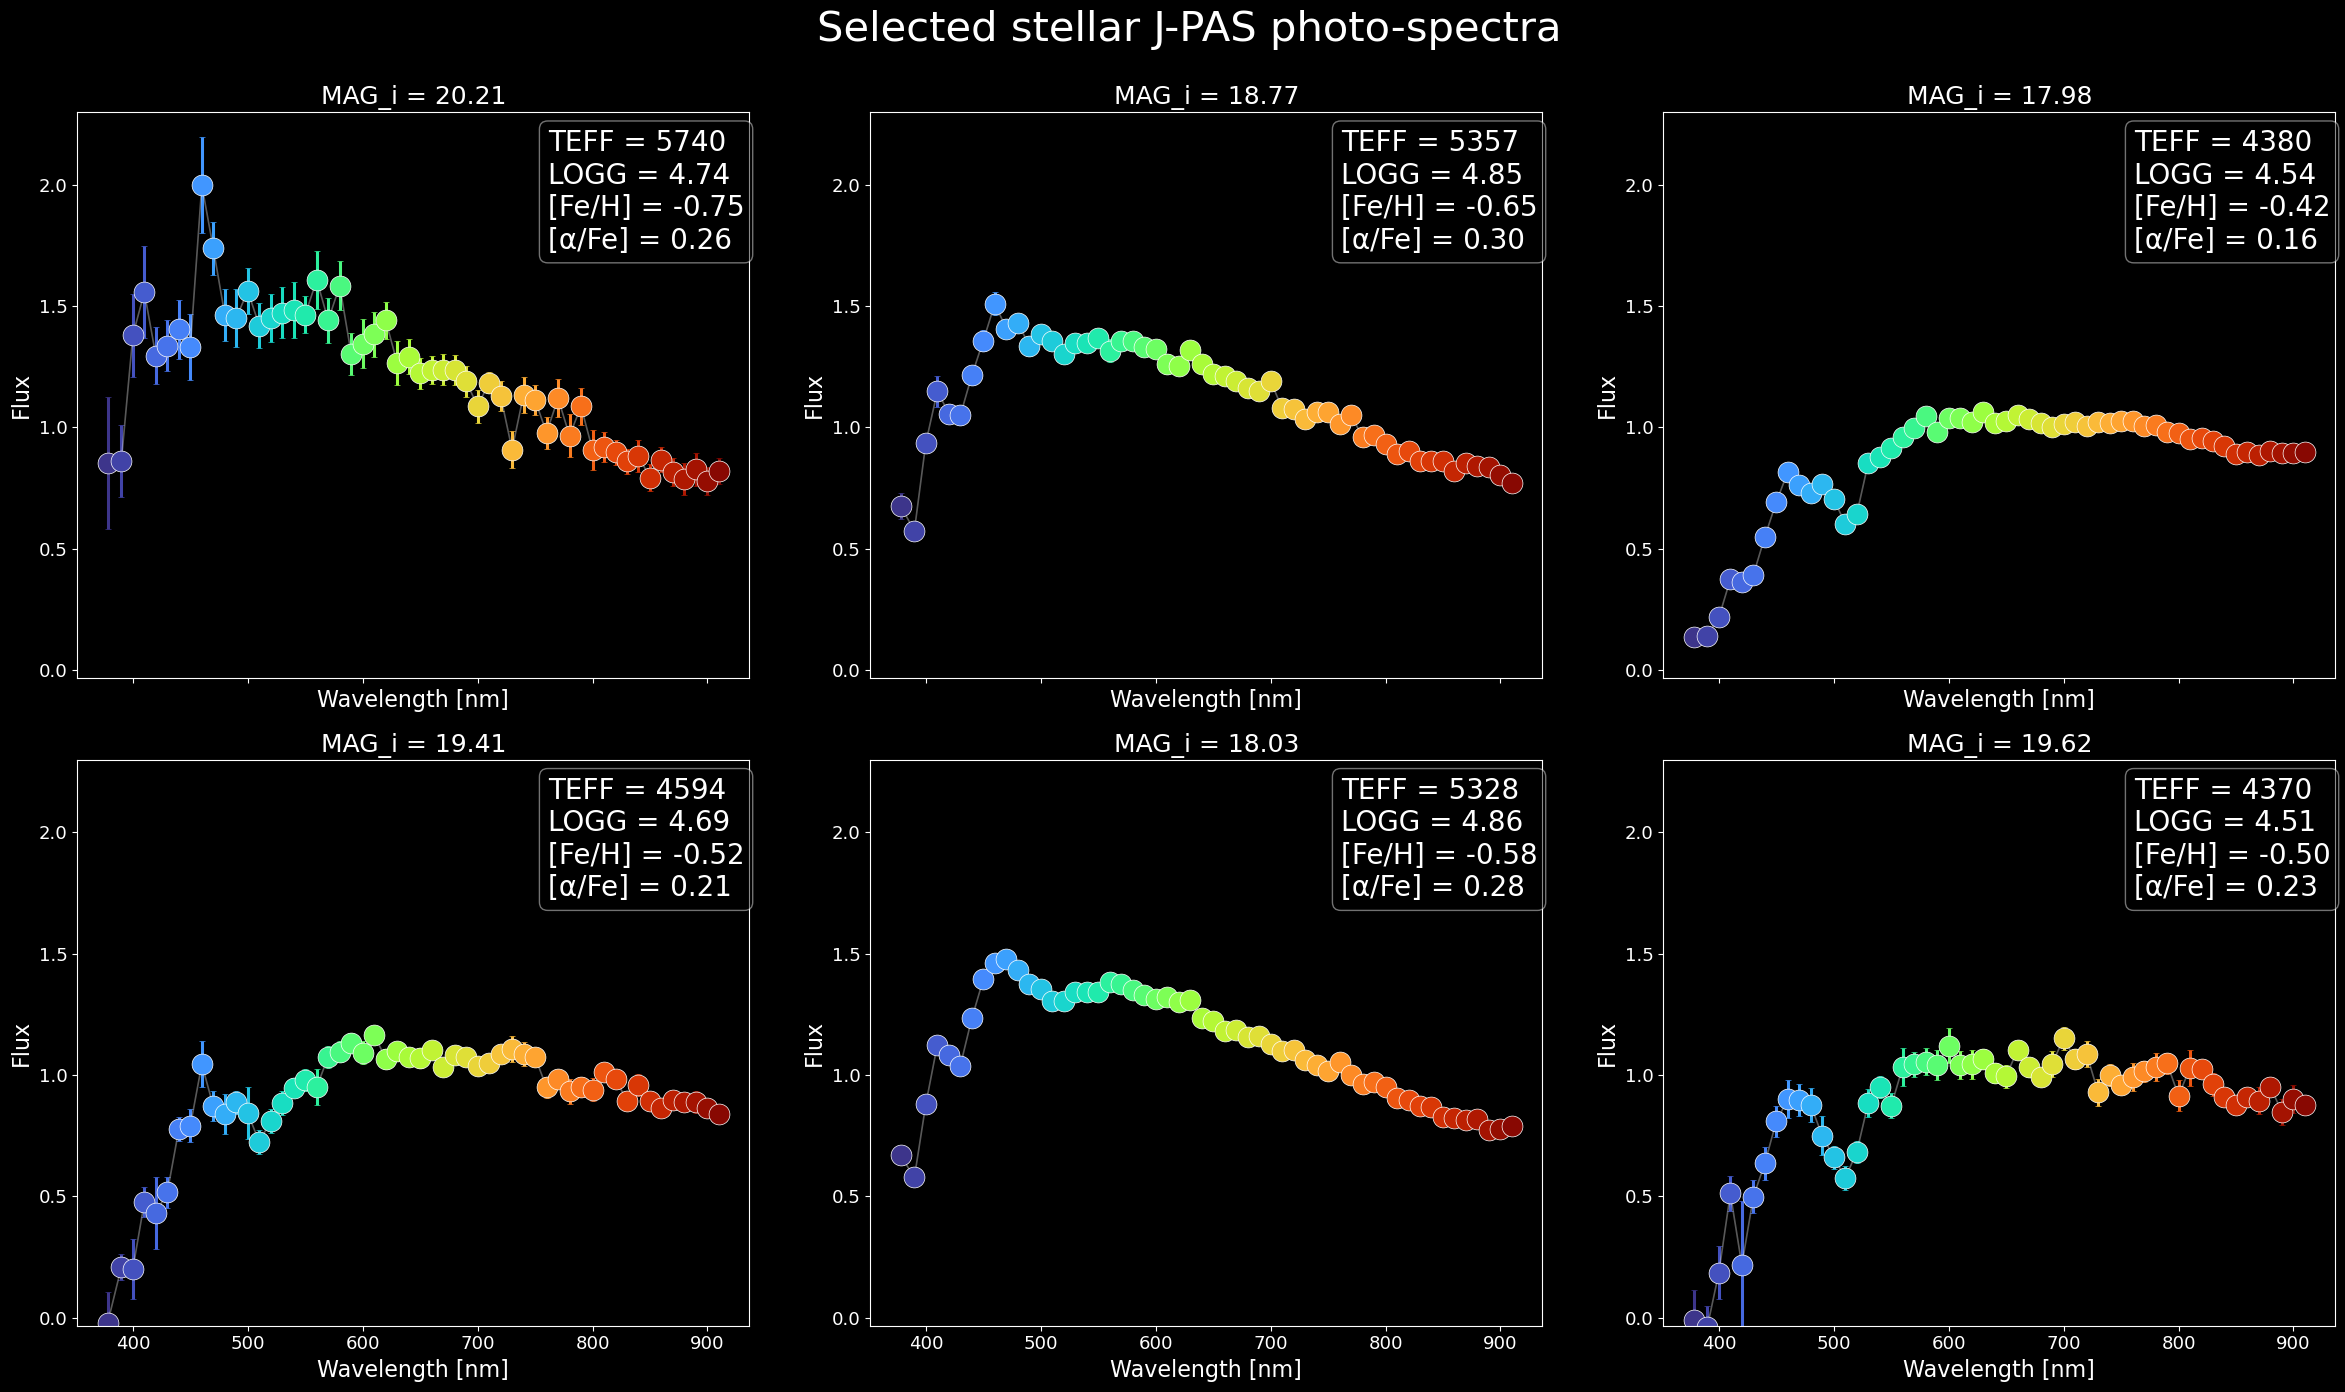

In [63]:
plot_source_df = example_star_df if len(example_star_df) > 0 else star_df

n_examples = min(N_RANDOM_STAR_EXAMPLES, len(plot_source_df))
plot_df = plot_source_df.sample(n=n_examples, random_state=RANDOM_SEED).copy()

ncols = 3
nrows = int(np.ceil(n_examples / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(24, 7 * nrows), sharex=True)
axes = np.atleast_1d(axes).ravel()

all_vals = plot_df[jpas_columns].values.flatten()
all_vals = all_vals[np.isfinite(all_vals)]
ylim = (np.min(all_vals) * 0.9, np.max(all_vals) * 1.15) if len(all_vals) > 0 else None

for i, ax in enumerate(axes):
    if i >= len(plot_df):
        ax.set_axis_off()
        continue

    row = plot_df.iloc[i]

    plot_panel_jpas_star(
        ax=ax,
        row=row,
        jpas_columns=jpas_columns,
        ylim=ylim,
        prefix=JPAS_PHOT_PREFIX,
    )

fig.suptitle("Selected stellar J-PAS photo-spectra", fontsize=30, y=0.995)
plt.tight_layout()
plt.show()

## 📊 Stellar parameter distributions

We now inspect the main stellar parameter space of the selected sample.

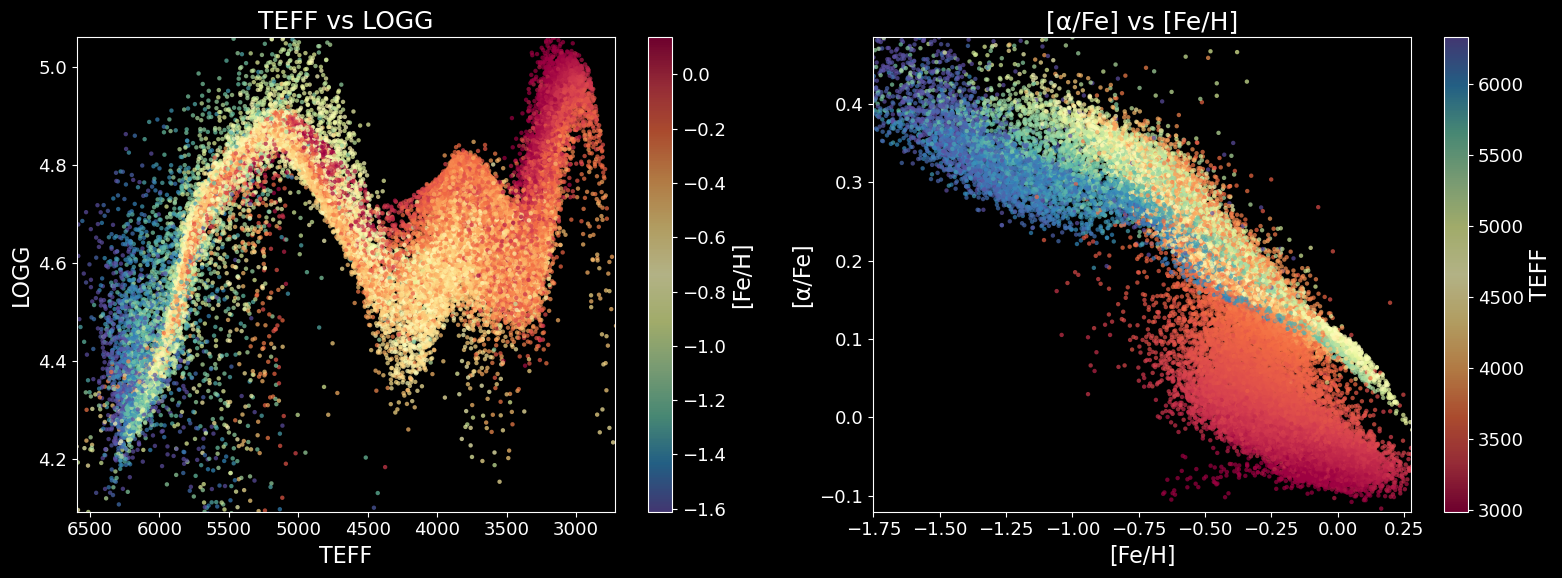

In [64]:
# ---------------------------------------------------------------------
# User-defined colorbar ranges
# Set to None to use automatic limits from the data
# ---------------------------------------------------------------------
FEH_CBAR_MIN = None
FEH_CBAR_MAX = None

TEFF_CBAR_MIN = None
TEFF_CBAR_MAX = None

teff = pd.to_numeric(star_df[TEFF_COL], errors="coerce").values
logg = pd.to_numeric(star_df[LOGG_COL], errors="coerce").values
feh = pd.to_numeric(star_df[FEH_COL], errors="coerce").values
alphafe = pd.to_numeric(star_df[ALPHAFE_COL], errors="coerce").values

mask_left = finite_mask(teff, logg, feh)
mask_right = finite_mask(feh, alphafe, teff)

feh_vmin = FEH_CBAR_MIN if FEH_CBAR_MIN is not None else np.nanquantile(feh[mask_left], 0.01)
feh_vmax = FEH_CBAR_MAX if FEH_CBAR_MAX is not None else np.nanquantile(feh[mask_left], 0.99)

teff_vmin = TEFF_CBAR_MIN if TEFF_CBAR_MIN is not None else np.nanquantile(teff[mask_right], 0.01)
teff_vmax = TEFF_CBAR_MAX if TEFF_CBAR_MAX is not None else np.nanquantile(teff[mask_right], 0.99)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: TEFF vs LOGG colored by [Fe/H]
sc1 = axes[0].scatter(
    teff[mask_left],
    logg[mask_left],
    c=feh[mask_left],
    cmap="Spectral_r",
    s=POINT_SIZE,
    alpha=ALPHA_SCATTER,
    edgecolors="none",
    vmin=feh_vmin,
    vmax=feh_vmax,
)

cbar1 = plt.colorbar(sc1, ax=axes[0])
cbar1.set_label("[Fe/H]")

axes[0].set_xlabel("TEFF")
axes[0].set_ylabel("LOGG")
axes[0].set_title("TEFF vs LOGG")
axes[0].set_xlim(*smart_limits(teff[mask_left], fallback=(3000, 9000)))
axes[0].set_ylim(*smart_limits(logg[mask_left], fallback=(0, 5.5)))
axes[0].invert_xaxis()
axes[0].grid(False)

# Right panel: [α/Fe] vs [Fe/H] colored by TEFF
sc2 = axes[1].scatter(
    feh[mask_right],
    alphafe[mask_right],
    c=teff[mask_right],
    cmap="Spectral",
    s=POINT_SIZE,
    alpha=ALPHA_SCATTER,
    edgecolors="none",
    vmin=teff_vmin,
    vmax=teff_vmax,
)

cbar2 = plt.colorbar(sc2, ax=axes[1])
cbar2.set_label("TEFF")

axes[1].set_xlabel("[Fe/H]")
axes[1].set_ylabel("[α/Fe]")
axes[1].set_title("[α/Fe] vs [Fe/H]")
axes[1].set_xlim(*smart_limits(feh[mask_right], fallback=(-3.0, 1.0)))
axes[1].set_ylim(*smart_limits(alphafe[mask_right], fallback=(-0.3, 0.8)))
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 💾 Save the stellar catalogue

Finally, we export the selected stellar sample.

In [47]:
output_subcatalog = OUTPUT_DIR / "star_catalog.csv"
star_df.to_csv(output_subcatalog, index=False)
print(f"Saved: {output_subcatalog}")

Saved: /Users/ginesmartinezsolaeche/Galaxies/OJALA_pipeline/data/catalogues/star_catalog.csv
